# **Problem Statement**

The company aims to analyze logistics and delivery operations data generated through transportation pipelines. The dataset contains trip-level and segment-level delivery information across multiple source and destination centers.

The objective is to clean, process, and transform raw operational data into meaningful features that can support business insights and forecasting models.

This analysis focuses on:
- Understanding data structure and quality
- Aggregating segment-level records into trip-level insights
- Performing exploratory data analysis (EDA)
- Creating useful features from time and location data
- Comparing actual delivery performance with OSRM estimates
- Detecting and handling missing values and outliers
- Preparing the dataset for machine learning and forecasting tasks

The overall goal is to improve delivery efficiency, operational visibility, and data-driven decision making.

# **Exploratory Data Analysis**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
!gdown 1DD2pozod4WfAISyj9hbUhD6VIX3hS7d-

Downloading...
From: https://drive.google.com/uc?id=1DD2pozod4WfAISyj9hbUhD6VIX3hS7d-
To: /content/delhivery_data.csv
100% 55.6M/55.6M [00:00<00:00, 93.7MB/s]


In [ ]:
df = pd.read_csv('delhivery_data.csv')

In [ ]:
df.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


In [ ]:
df.shape

(144867, 24)

In [ ]:
df.columns.tolist()

['data',
 'trip_creation_time',
 'route_schedule_uuid',
 'route_type',
 'trip_uuid',
 'source_center',
 'source_name',
 'destination_center',
 'destination_name',
 'od_start_time',
 'od_end_time',
 'start_scan_to_end_scan',
 'is_cutoff',
 'cutoff_factor',
 'cutoff_timestamp',
 'actual_distance_to_destination',
 'actual_time',
 'osrm_time',
 'osrm_distance',
 'factor',
 'segment_actual_time',
 'segment_osrm_time',
 'segment_osrm_distance',
 'segment_factor']

In [ ]:
#entire data columns and data type information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff       

In [ ]:
missing_values = pd.DataFrame({'Missing_Count': df.isnull().sum(), 'Missing_Percentage': (df.isnull().sum()/len(df))*100})
missing_values = missing_values[missing_values['Missing_Count'] > 0]
print("Missing Values Summary:")
display(missing_values.sort_values(by='Missing_Percentage', ascending=False))

Missing Values Summary:


,Missing_Count,Missing_Percentage
source_name,293,0.202254
destination_name,261,0.180165


In [ ]:
print("Statistical Summary of Numerical Columns:")
display(df.describe())

Statistical Summary of Numerical Columns:


,start_scan_to_end_scan,cutoff_factor,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
count,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.00000,144867.000000
mean,961.262986,232.926567,234.073372,416.927527,213.868272,284.771297,2.120107,36.196111,18.507548,22.82902,2.218368
std,1037.012769,344.755577,344.990009,598.103621,308.011085,421.119294,1.715421,53.571158,14.775960,17.86066,4.847530
min,20.000000,9.000000,9.000045,9.000000,6.000000,9.008200,0.144000,-244.000000,0.000000,0.00000,-23.444444
25%,161.000000,22.000000,23.355874,51.000000,27.000000,29.914700,1.604264,20.000000,11.000000,12.07010,1.347826
50%,449.000000,66.000000,66.126571,132.000000,64.000000,78.525800,1.857143,29.000000,17.000000,23.51300,1.684211
75%,1634.000000,286.000000,286.708875,513.000000,257.000000,343.193250,2.213483,40.000000,22.000000,27.81325,2.250000
max,7898.000000,1927.000000,1927.447705,4532.000000,1686.000000,2326.199100,77.387097,3051.000000,1611.000000,2191.40370,574.250000


In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical Columns:")
print(categorical_cols)

print("Numerical Columns:")
print(numerical_cols)

Categorical Columns:
['data', 'trip_creation_time', 'route_schedule_uuid', 'route_type', 'trip_uuid', 'source_center', 'source_name', 'destination_center', 'destination_name', 'od_start_time', 'od_end_time', 'cutoff_timestamp']
Numerical Columns:
['start_scan_to_end_scan', 'cutoff_factor', 'actual_distance_to_destination', 'actual_time', 'osrm_time', 'osrm_distance', 'factor', 'segment_actual_time', 'segment_osrm_time', 'segment_osrm_distance', 'segment_factor']


# Initial Observations

- The dataset contains 144,867 records and 24 columns.
- Missing values are very low and are present only in:
  - source_name
  - destination_name
- Most numerical variables show a large spread between minimum and maximum values, indicating the possible presence of outliers.
- Variables such as:
  - actual_time
  - osrm_time
  - osrm_distance
  - segment_actual_time
  contain high standard deviations, suggesting variability in trip performance.
- Negative values are observed in:
  - segment_actual_time
  - segment_factor
  which may indicate data quality issues or abnormal operational records.
- Several columns are categorical/object type and may require datatype optimization and encoding in later stages.
- Timestamp-related columns are currently stored as object datatype and will require datetime conversion.
- The dataset appears to contain multiple rows per trip_uuid, confirming the presence of segment level delivery records.


# Missing value treatment

In [ ]:
df['source_name'] = df['source_name'].fillna(df['source_center'])
df['destination_name'] = df['destination_name'].fillna(df['destination_center'])
df[['source_name','destination_name']].isnull().sum()

,0
source_name,0
destination_name,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144867 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144867 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff       

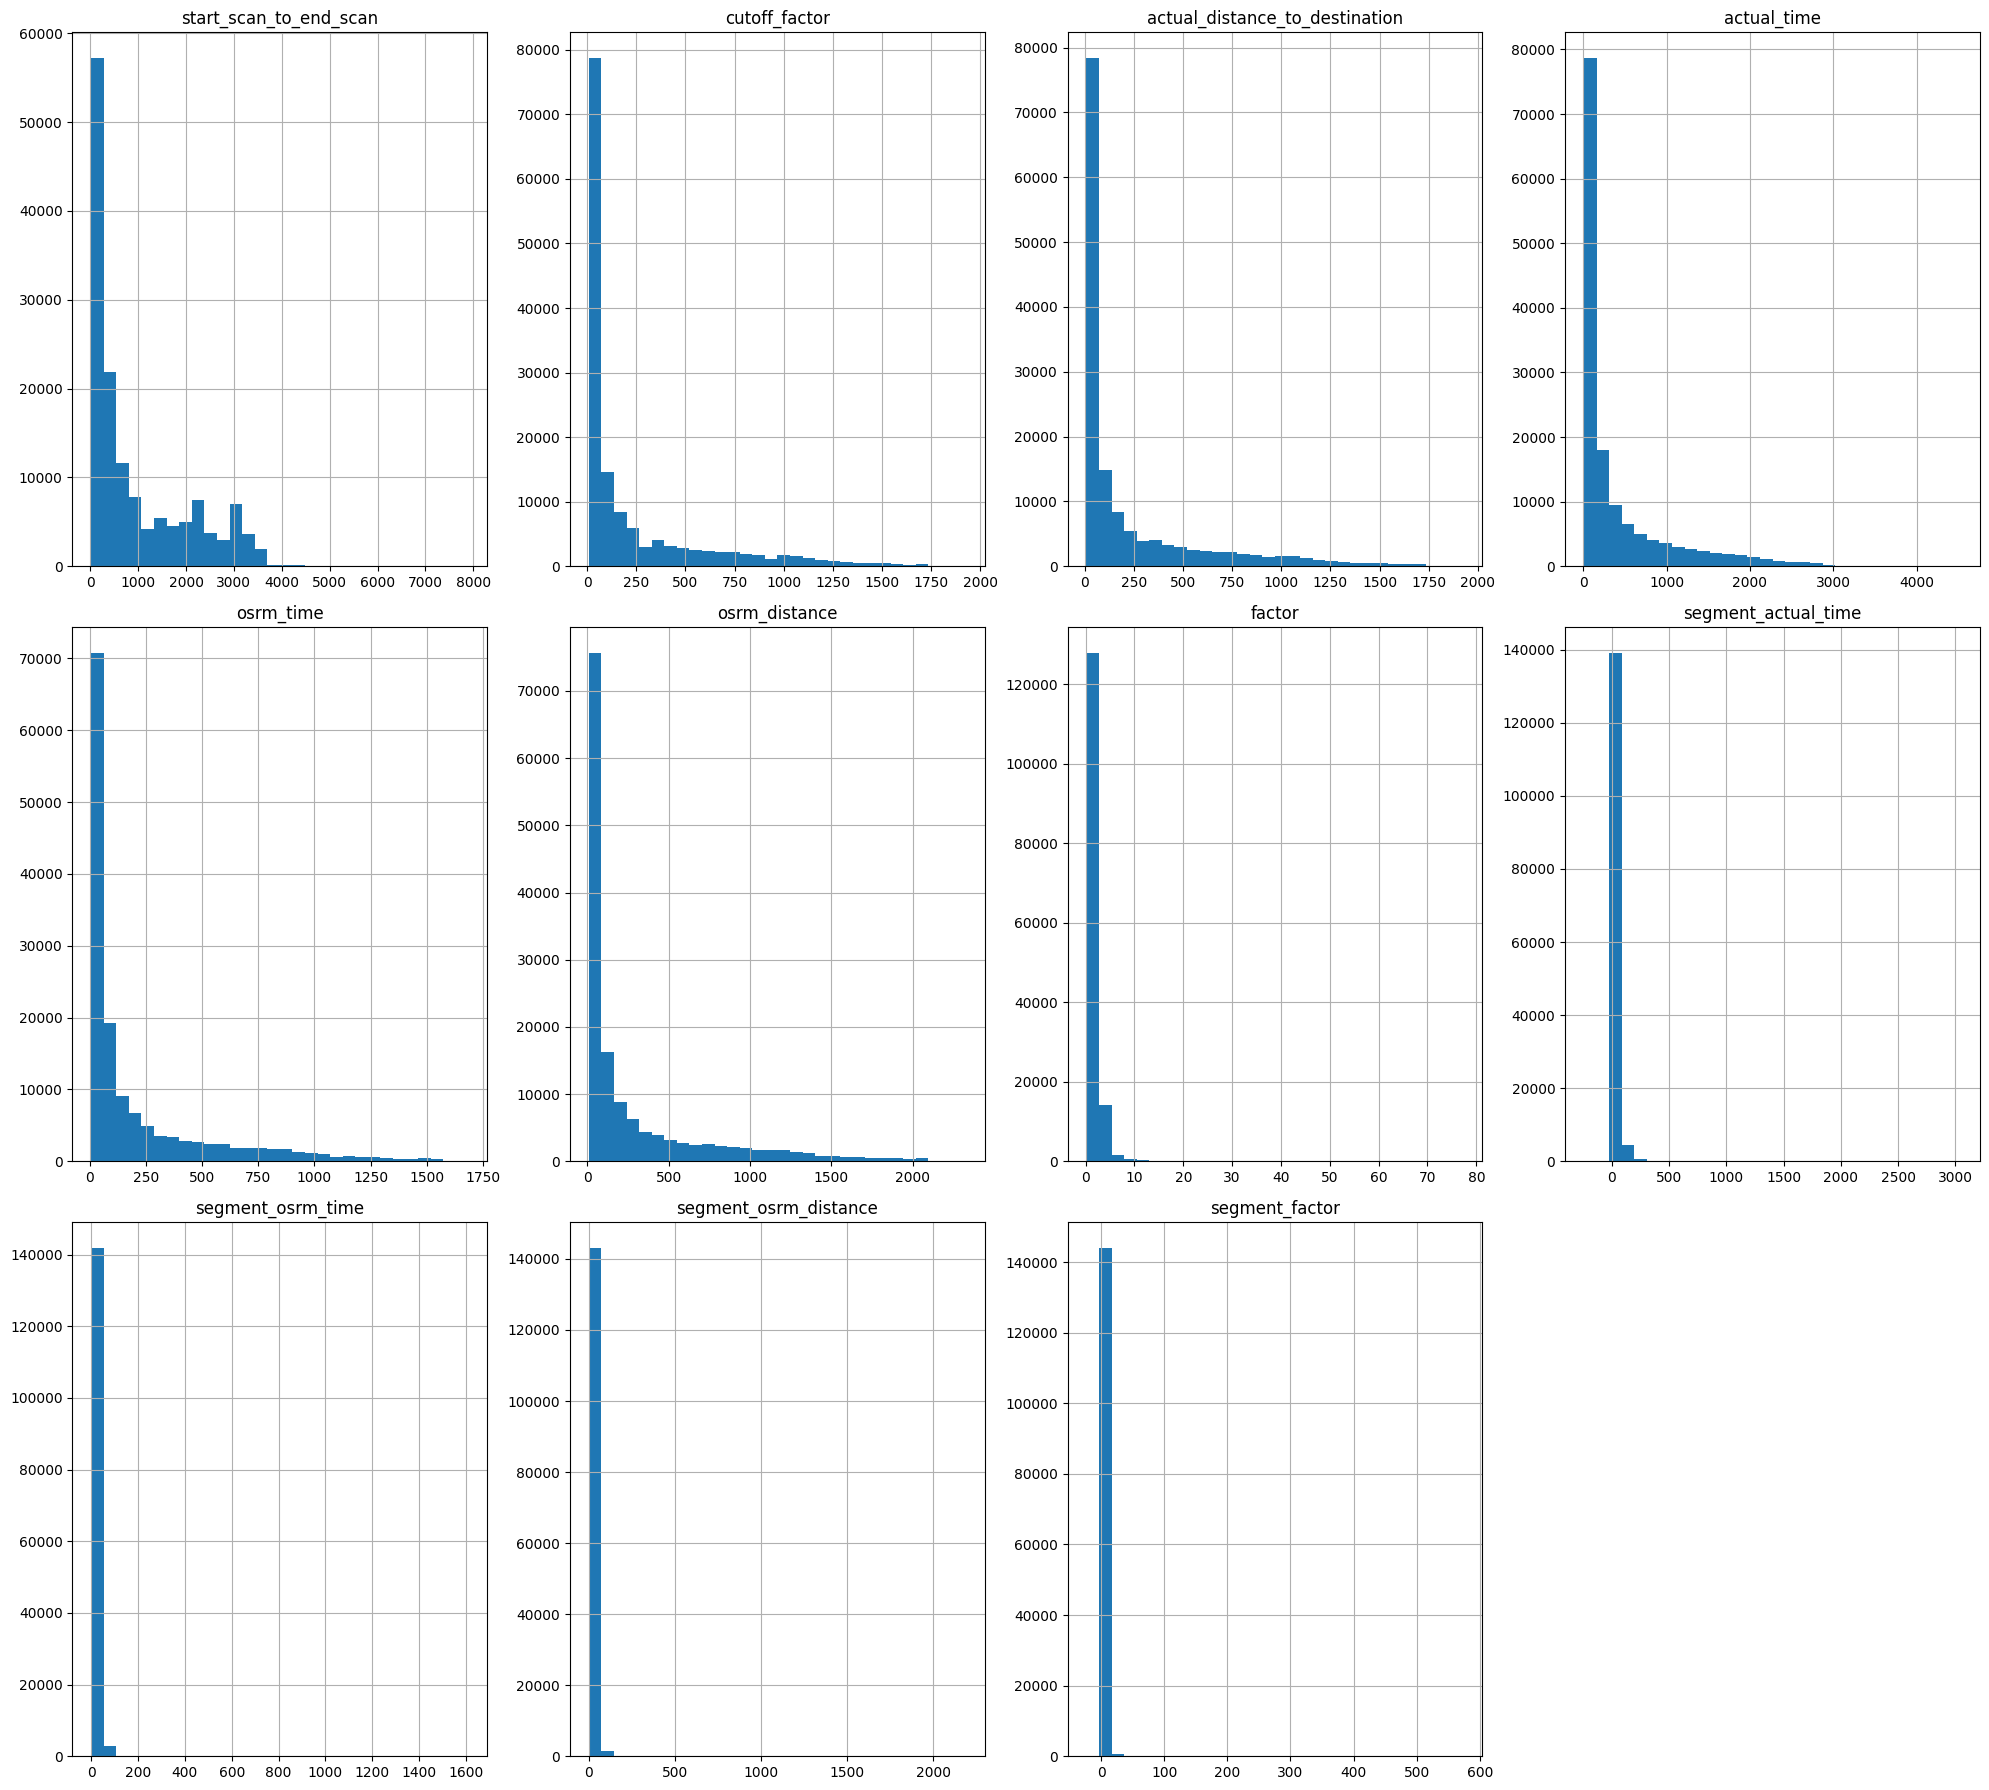

In [ ]:
df[numerical_cols].hist(figsize=(20,18), bins=30, layout=(3,4))
plt.tight_layout()
plt.show()

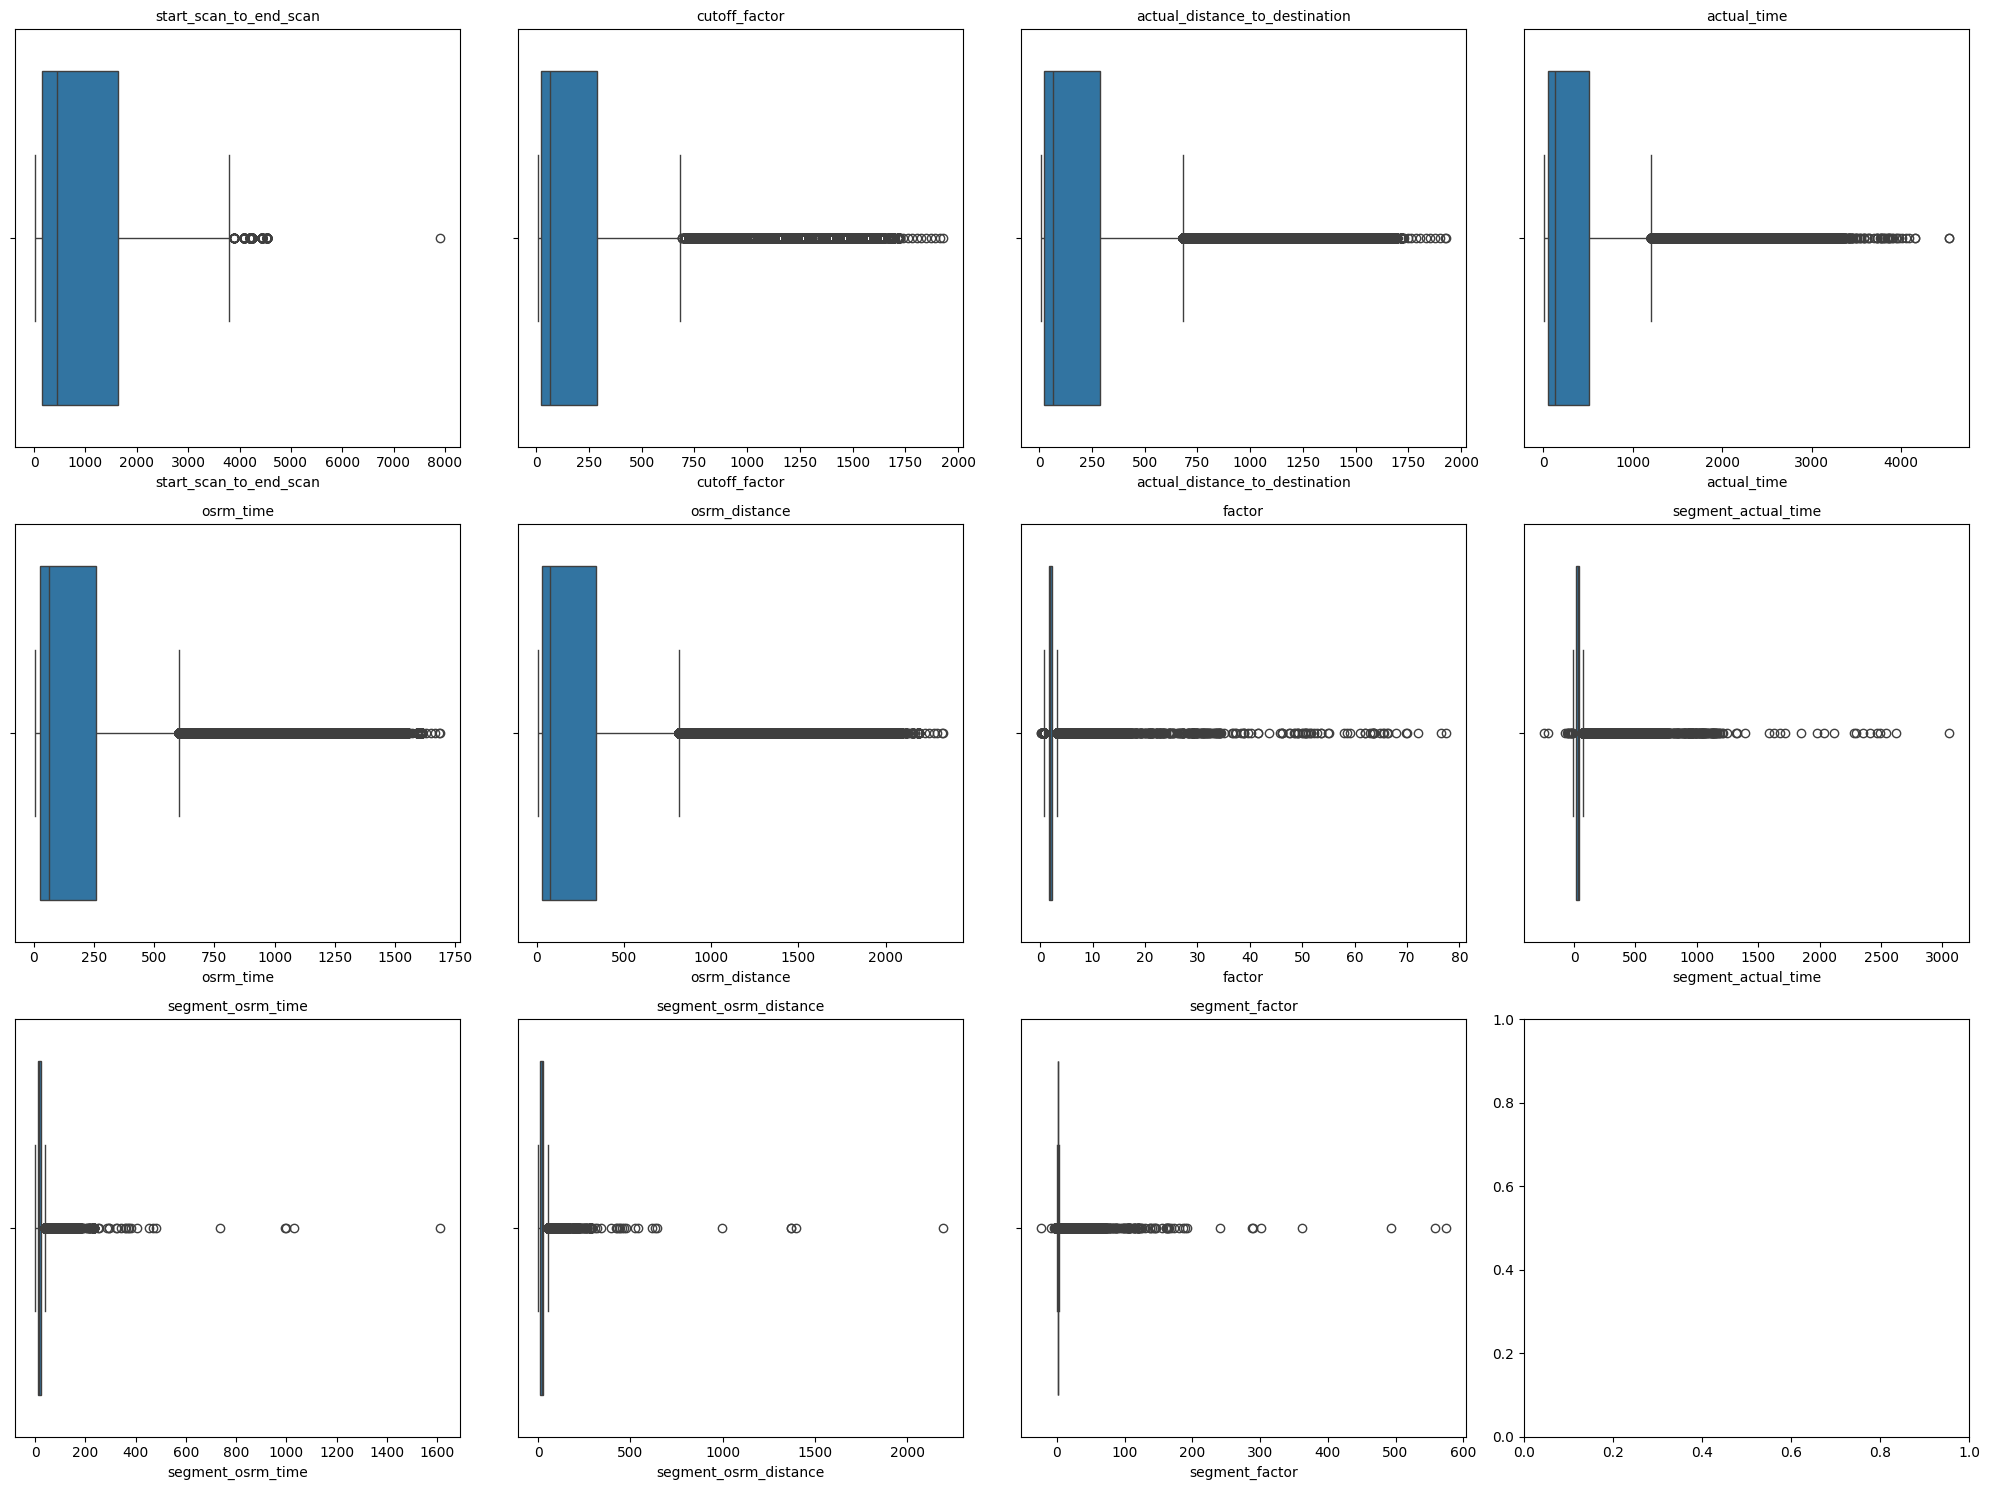

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20,15))

axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=10)

plt.tight_layout()
plt.show()

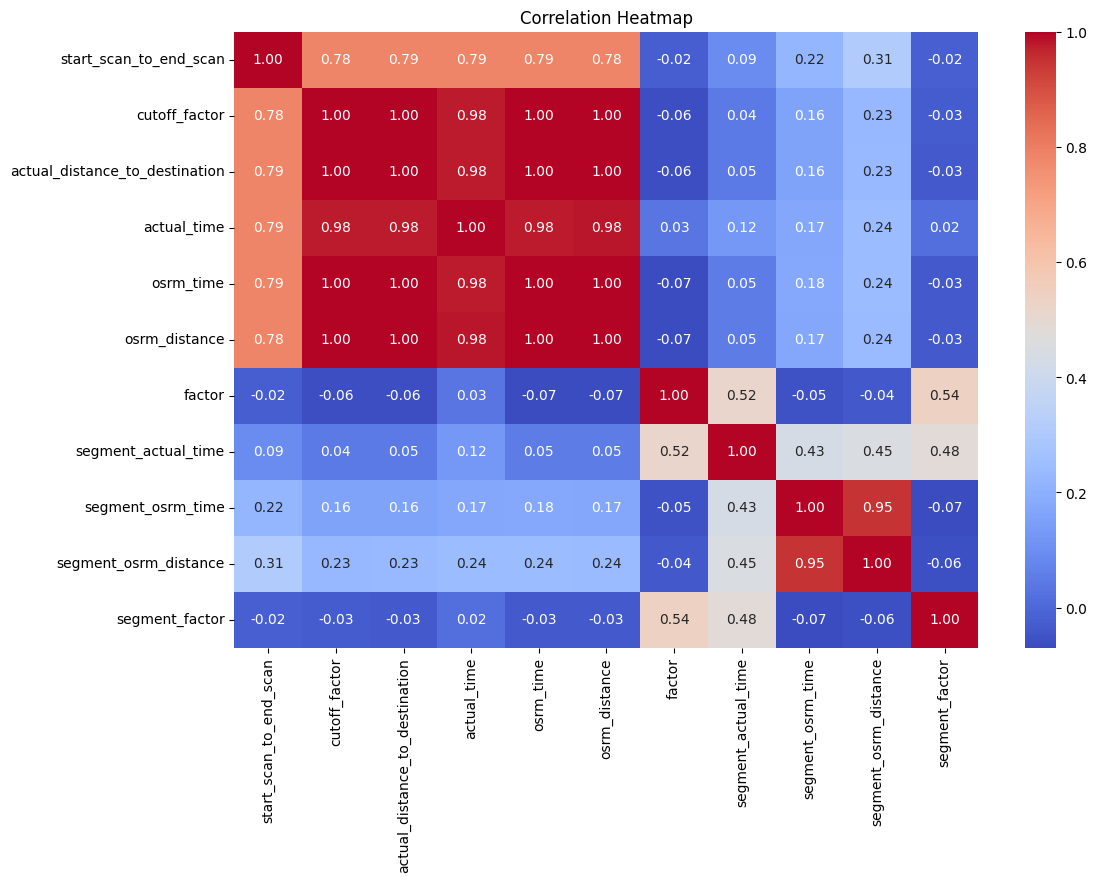

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Insights from EDA

## Univariate Analysis

- Most numerical variables are highly right-skewed, indicating that most trips have lower delivery times/distances while a smaller number of trips have very high values.
- Variables such as actual_time, osrm_time, osrm_distance, and actual_distance_to_destination show large spread and variability in delivery operations.
- Segment-level variables are comparatively concentrated around smaller values since they represent partial trip movements.
- Negative values observed in segment_actual_time and segment_factor indicate possible data quality issues or abnormal operational records.

## Outlier Analysis

- Significant outliers are present across almost all numerical variables, especially in time and distance-related features.
- Extreme values may occur due to long-distance routes, traffic conditions, operational delays, or exceptional delivery cases.
- Outlier treatment will be important before model building and scaling.

## Bivariate Analysis

- Strong positive correlations exist among:
  - actual_time
  - osrm_time
  - osrm_distance
  - actual_distance_to_destination

- actual_time is highly correlated with osrm_time and osrm_distance, indicating that OSRM estimates closely align with actual delivery behavior.

- segment_osrm_time and segment_osrm_distance also show strong correlation, suggesting consistency in segment-level route estimation.

- factor and segment_factor show weak relationships with most operational variables and may represent efficiency or deviation-based metrics.

## Overall Insights

- The dataset contains highly variable logistics operations with multiple extreme observations.
- Multiple rows per trip_uuid confirm the presence of segment-level delivery data.
- High correlations among several variables may create multicollinearity during modeling and should be considered during feature selection.
- The dataset requires preprocessing steps such as aggregation, outlier handling, encoding, and scaling before machine learning applications.

# Feature creation

In [ ]:
df['source_state'] = df['source_name'].str.extract(r'\((.*?)\)')
df['destination_state'] = df['destination_name'].str.extract(r'\((.*?)\)')

In [ ]:
df['source_city'] = df['source_name'].str.split('_').str[0]
df['destination_city'] = df['destination_name'].str.split('_').str[0]

In [ ]:
df[['source_name','source_city','source_state','destination_name','destination_city','destination_state']].head()

,source_name,source_city,source_state,destination_name,destination_city,destination_state
0,Anand_VUNagar_DC (Gujarat),Anand,Gujarat,Khambhat_MotvdDPP_D (Gujarat),Khambhat,Gujarat
1,Anand_VUNagar_DC (Gujarat),Anand,Gujarat,Khambhat_MotvdDPP_D (Gujarat),Khambhat,Gujarat
2,Anand_VUNagar_DC (Gujarat),Anand,Gujarat,Khambhat_MotvdDPP_D (Gujarat),Khambhat,Gujarat
3,Anand_VUNagar_DC (Gujarat),Anand,Gujarat,Khambhat_MotvdDPP_D (Gujarat),Khambhat,Gujarat
4,Anand_VUNagar_DC (Gujarat),Anand,Gujarat,Khambhat_MotvdDPP_D (Gujarat),Khambhat,Gujarat


In [ ]:
df['trip_creation_time'] = pd.to_datetime(df['trip_creation_time'])

In [ ]:
df['trip_year'] = df['trip_creation_time'].dt.year
df['trip_month'] = df['trip_creation_time'].dt.month
df['trip_day'] = df['trip_creation_time'].dt.day
df['trip_hour'] = df['trip_creation_time'].dt.hour
df['trip_dayofweek'] = df['trip_creation_time'].dt.day_name()

In [ ]:
df[['trip_creation_time','trip_year','trip_month','trip_day','trip_hour','trip_dayofweek']].head()

,trip_creation_time,trip_year,trip_month,trip_day,trip_hour,trip_dayofweek
0,2018-09-20 02:35:36.476840,2018,9,20,2,Thursday
1,2018-09-20 02:35:36.476840,2018,9,20,2,Thursday
2,2018-09-20 02:35:36.476840,2018,9,20,2,Thursday
3,2018-09-20 02:35:36.476840,2018,9,20,2,Thursday
4,2018-09-20 02:35:36.476840,2018,9,20,2,Thursday


# Feature Creation Insights

- Extracted source_city, destination_city, source_state, and destination_state from location fields for regional and route-level analysis.
- Converted trip_creation_time into datetime format and extracted:
  - year
  - month
  - day
  - hour
  - weekday

- These features improve data interpretability and help in trend analysis, operational insights, and forecasting model preparation.

# Merging of rows and aggregation of fields

In [ ]:
trip_segment = df.groupby(['trip_uuid','source_center','destination_center']).agg({
    'data':'first',
    'trip_creation_time':'first',
    'route_schedule_uuid':'first',
    'route_type':'first',
    'source_name':'first',
    'destination_name':'first',
    'od_start_time':'first',
    'od_end_time':'last',
    'start_scan_to_end_scan':'max',
    'actual_distance_to_destination':'max',
    'actual_time':'max',
    'osrm_time':'max',
    'osrm_distance':'max',
    'segment_actual_time':'sum',
    'segment_osrm_time':'sum',
    'segment_osrm_distance':'sum',
    'source_city':'first',
    'source_state':'first',
    'destination_city':'first',
    'destination_state':'first'
}).reset_index()

In [ ]:
print(trip_segment.shape)
trip_segment.head()

(26368, 23)


,trip_uuid,source_center,destination_center,data,trip_creation_time,route_schedule_uuid,route_type,source_name,destination_name,od_start_time,...,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,source_city,source_state,destination_city,destination_state
0,trip-153671041653548748,IND209304AAA,IND000000ACB,training,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,Kanpur_Central_H_6 (Uttar Pradesh),Gurgaon_Bilaspur_HB (Haryana),2018-09-12 16:39:46.858469,...,732.0,349.0,446.5496,728.0,534.0,670.6205,Kanpur,Uttar Pradesh,Gurgaon,Haryana
1,trip-153671041653548748,IND462022AAA,IND209304AAA,training,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,Bhopal_Trnsport_H (Madhya Pradesh),Kanpur_Central_H_6 (Uttar Pradesh),2018-09-12 00:00:16.535741,...,830.0,394.0,544.8027,820.0,474.0,649.8528,Bhopal,Madhya Pradesh,Kanpur,Uttar Pradesh
2,trip-153671042288605164,IND561203AAB,IND562101AAA,training,2018-09-12 00:00:22.886430,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0...,Carting,Doddablpur_ChikaDPP_D (Karnataka),Chikblapur_ShntiSgr_D (Karnataka),2018-09-12 02:03:09.655591,...,47.0,26.0,28.1994,46.0,26.0,28.1995,Doddablpur,Karnataka,Chikblapur,Karnataka
3,trip-153671042288605164,IND572101AAA,IND561203AAB,training,2018-09-12 00:00:22.886430,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0...,Carting,Tumkur_Veersagr_I (Karnataka),Doddablpur_ChikaDPP_D (Karnataka),2018-09-12 00:00:22.886430,...,96.0,42.0,56.9116,95.0,39.0,55.9899,Tumkur,Karnataka,Doddablpur,Karnataka
4,trip-153671043369099517,IND000000ACB,IND160002AAC,training,2018-09-12 00:00:33.691250,thanos::sroute:de5e208e-7641-45e6-8100-4d9fb1e...,FTL,Gurgaon_Bilaspur_HB (Haryana),Chandigarh_Mehmdpur_H (Punjab),2018-09-14 03:40:17.106733,...,611.0,212.0,281.2109,608.0,231.0,317.7408,Gurgaon,Haryana,Chandigarh,Punjab


# Observations after Segment-Level Aggregation

- Multiple segment-level rows were merged using trip_uuid, source_center, and destination_center.
- Dataset size reduced from 144,867 rows to 26,368 rows after aggregation.
- Segment-level variables such as segment_actual_time, segment_osrm_time, and segment_osrm_distance were aggregated using sum().
- Cumulative trip variables such as actual_time, osrm_time, and osrm_distance were aggregated using max() to preserve final trip values.
- Categorical columns were retained using first() and last() wherever appropriate.
- Aggregation converted fragmented shipment movements into meaningful route-level delivery records suitable for further analysis.

#	Comparison & Visualization of time and distance fields

In [ ]:
trip_df = trip_segment.groupby('trip_uuid').agg({
    'data':'first',
    'trip_creation_time':'first',
    'route_schedule_uuid':'first',
    'route_type':'first',
    'source_center':'first',
    'destination_center':'last',
    'source_name':'first',
    'destination_name':'last',
    'od_start_time':'first',
    'od_end_time':'last',
    'start_scan_to_end_scan':'sum',
    'actual_distance_to_destination':'sum',
    'actual_time':'sum',
    'osrm_time':'sum',
    'osrm_distance':'sum',
    'segment_actual_time':'sum',
    'segment_osrm_time':'sum',
    'segment_osrm_distance':'sum',
    'source_city':'first',
    'source_state':'first',
    'destination_city':'last',
    'destination_state':'last'
}).reset_index()

In [ ]:
print(trip_df.shape)
trip_df.head()

(14817, 23)


,trip_uuid,data,trip_creation_time,route_schedule_uuid,route_type,source_center,destination_center,source_name,destination_name,od_start_time,...,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,source_city,source_state,destination_city,destination_state
0,trip-153671041653548748,training,2018-09-12 00:00:16.535741,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,IND209304AAA,IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),Kanpur_Central_H_6 (Uttar Pradesh),2018-09-12 16:39:46.858469,...,1562.0,743.0,991.3523,1548.0,1008.0,1320.4733,Kanpur,Uttar Pradesh,Kanpur,Uttar Pradesh
1,trip-153671042288605164,training,2018-09-12 00:00:22.886430,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0...,Carting,IND561203AAB,IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),Doddablpur_ChikaDPP_D (Karnataka),2018-09-12 02:03:09.655591,...,143.0,68.0,85.1110,141.0,65.0,84.1894,Doddablpur,Karnataka,Doddablpur,Karnataka
2,trip-153671043369099517,training,2018-09-12 00:00:33.691250,thanos::sroute:de5e208e-7641-45e6-8100-4d9fb1e...,FTL,IND000000ACB,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),Gurgaon_Bilaspur_HB (Haryana),2018-09-14 03:40:17.106733,...,3347.0,1741.0,2372.0852,3308.0,1941.0,2545.2678,Gurgaon,Haryana,Gurgaon,Haryana
3,trip-153671046011330457,training,2018-09-12 00:01:00.113710,thanos::sroute:f0176492-a679-4597-8332-bbd1c7f...,Carting,IND400072AAB,IND401104AAA,Mumbai Hub (Maharashtra),Mumbai_MiraRd_IP (Maharashtra),2018-09-12 00:01:00.113710,...,59.0,15.0,19.6800,59.0,16.0,19.8766,Mumbai Hub (Maharashtra),Maharashtra,Mumbai,Maharashtra
4,trip-153671052974046625,training,2018-09-12 00:02:09.740725,thanos::sroute:d9f07b12-65e0-4f3b-bec8-df06134...,FTL,IND583101AAA,IND583119AAA,Bellary_Dc (Karnataka),Sandur_WrdN1DPP_D (Karnataka),2018-09-12 00:02:09.740725,...,341.0,117.0,146.7918,340.0,115.0,146.7919,Bellary,Karnataka,Sandur,Karnataka


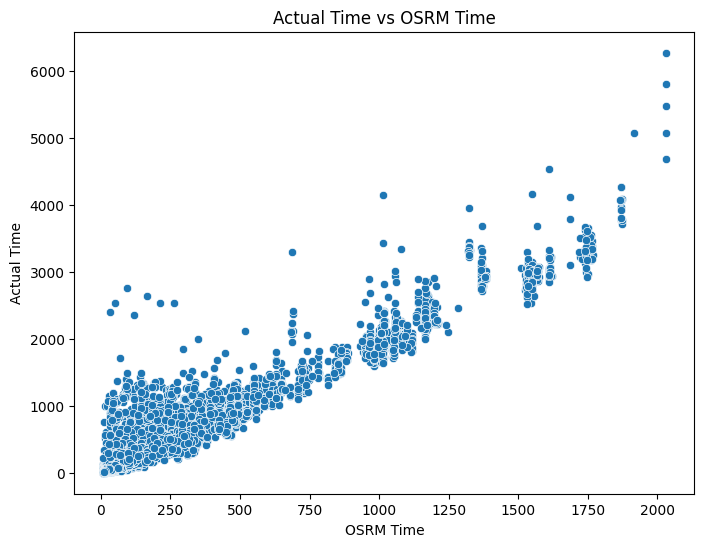

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=trip_df['osrm_time'], y=trip_df['actual_time'])
plt.xlabel('OSRM Time')
plt.ylabel('Actual Time')
plt.title('Actual Time vs OSRM Time')
plt.show()

In [ ]:
trip_df[['actual_time','osrm_time']].corr()

,actual_time,osrm_time
actual_time,1.00000,0.95859
osrm_time,0.95859,1.00000


# Observations: Actual Time vs OSRM Time

- Strong positive correlation (~0.96) is observed between actual_time and osrm_time.
- Scatterplot shows a clear upward trend, indicating that higher estimated route time generally leads to higher actual delivery time.
- Actual delivery time is usually higher than OSRM estimated time, which may be due to:
  - traffic conditions,
  - operational delays,
  - loading/unloading time,
  - and real-world logistics constraints.
- Few extreme outliers are visible for high delivery durations.
- OSRM time appears to be a strong predictor of actual delivery performance.

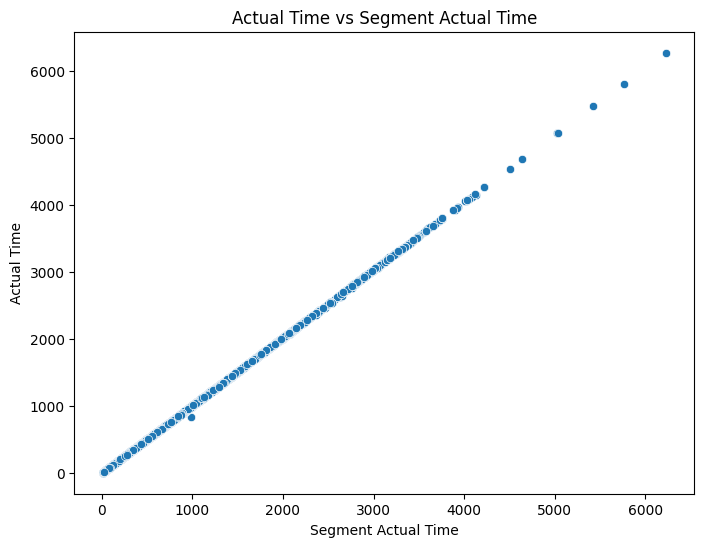

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=trip_df['segment_actual_time'], y=trip_df['actual_time'])
plt.xlabel('Segment Actual Time')
plt.ylabel('Actual Time')
plt.title('Actual Time vs Segment Actual Time')
plt.show()

In [ ]:
trip_df[['actual_time','segment_actual_time']].corr()

,actual_time,segment_actual_time
actual_time,1.000000,0.999989
segment_actual_time,0.999989,1.000000


# Observations: Actual Time vs Segment Actual Time

- Extremely high positive correlation (~1.00) is observed between actual_time and segment_actual_time.
- Scatterplot shows an almost perfect linear relationship between both variables.
- This indicates that aggregated segment_actual_time closely reconstructs the total actual trip time.
- The aggregation logic used for segment-level records is consistent and reliable.
- Very minimal deviation is observed between both metrics.

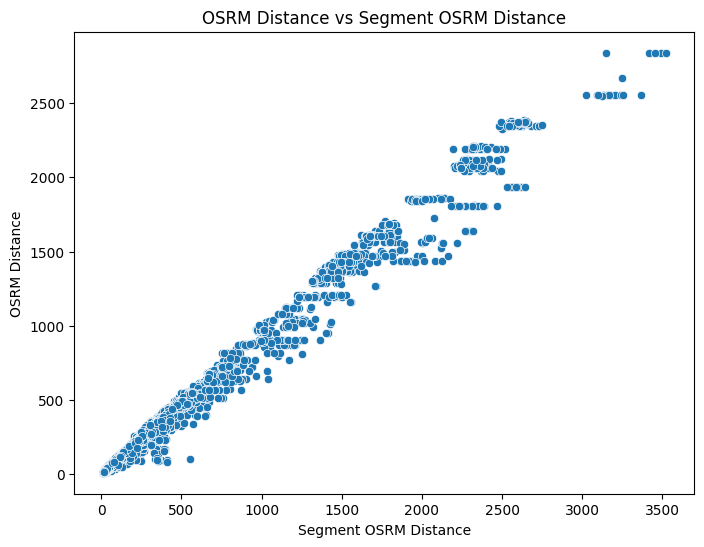

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=trip_df['segment_osrm_distance'], y=trip_df['osrm_distance'])
plt.xlabel('Segment OSRM Distance')
plt.ylabel('OSRM Distance')
plt.title('OSRM Distance vs Segment OSRM Distance')
plt.show()

In [ ]:
trip_df[['osrm_distance','segment_osrm_distance']].corr()

,osrm_distance,segment_osrm_distance
osrm_distance,1.000000,0.994963
segment_osrm_distance,0.994963,1.000000


# Observations: OSRM Distance vs Segment OSRM Distance

- Very strong positive correlation (~0.99) is observed between osrm_distance and segment_osrm_distance.
- Scatterplot shows a strong linear relationship, indicating consistency between aggregated segment distances and total OSRM route distance.
- Minor deviations are visible in some trips, likely due to route segmentation or cumulative estimation differences.
- The aggregation approach effectively preserves overall route distance information.

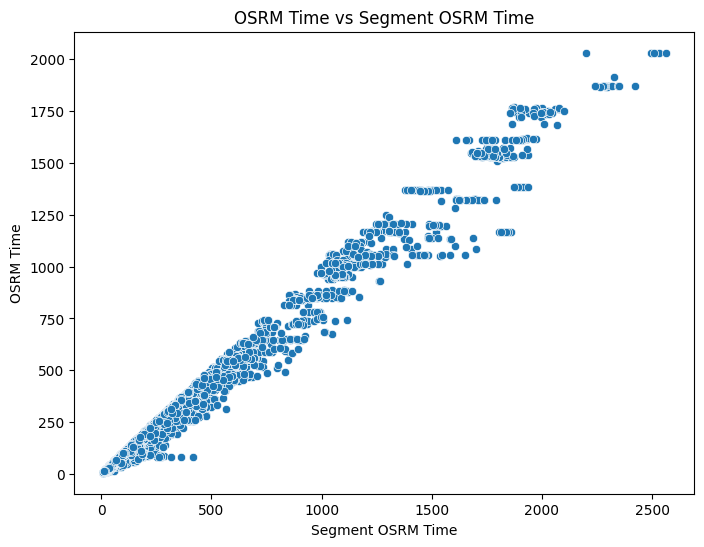

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=trip_df['segment_osrm_time'], y=trip_df['osrm_time'])
plt.xlabel('Segment OSRM Time')
plt.ylabel('OSRM Time')
plt.title('OSRM Time vs Segment OSRM Time')
plt.show()

In [ ]:
trip_df[['osrm_time','segment_osrm_time']].corr()

,osrm_time,segment_osrm_time
osrm_time,1.000000,0.993551
segment_osrm_time,0.993551,1.000000


# Observations: OSRM Time vs Segment OSRM Time

- Very strong positive correlation (~0.99) is observed between osrm_time and segment_osrm_time.
- Scatterplot shows a strong linear relationship, indicating that aggregated segment OSRM times closely match total OSRM trip time.
- Most observations are densely concentrated along the diagonal line, confirming consistency in route estimation.
- Horizontal band patterns at higher values suggest grouping of trips with similar estimated travel durations.
- Minor deviations and sparse outliers are visible for longer trips, possibly due to route segmentation differences.

# Missing values Treatment & Outlier treatment

In [ ]:
trip_df.isnull().sum()

,0
trip_uuid,0
data,0
trip_creation_time,0
route_schedule_uuid,0
route_type,0
source_center,0
destination_center,0
source_name,0
destination_name,0
od_start_time,0


In [ ]:
trip_df['source_state'] = trip_df['source_state'].fillna(trip_df['destination_state'])

In [ ]:
trip_df['source_state'] = trip_df['source_state'].fillna('Unknown')

In [ ]:
trip_df.isnull().sum()

,0
trip_uuid,0
data,0
trip_creation_time,0
route_schedule_uuid,0
route_type,0
source_center,0
destination_center,0
source_name,0
destination_name,0
od_start_time,0


In [ ]:
num_cols_trip = trip_df.select_dtypes(include=['int64','float64']).columns

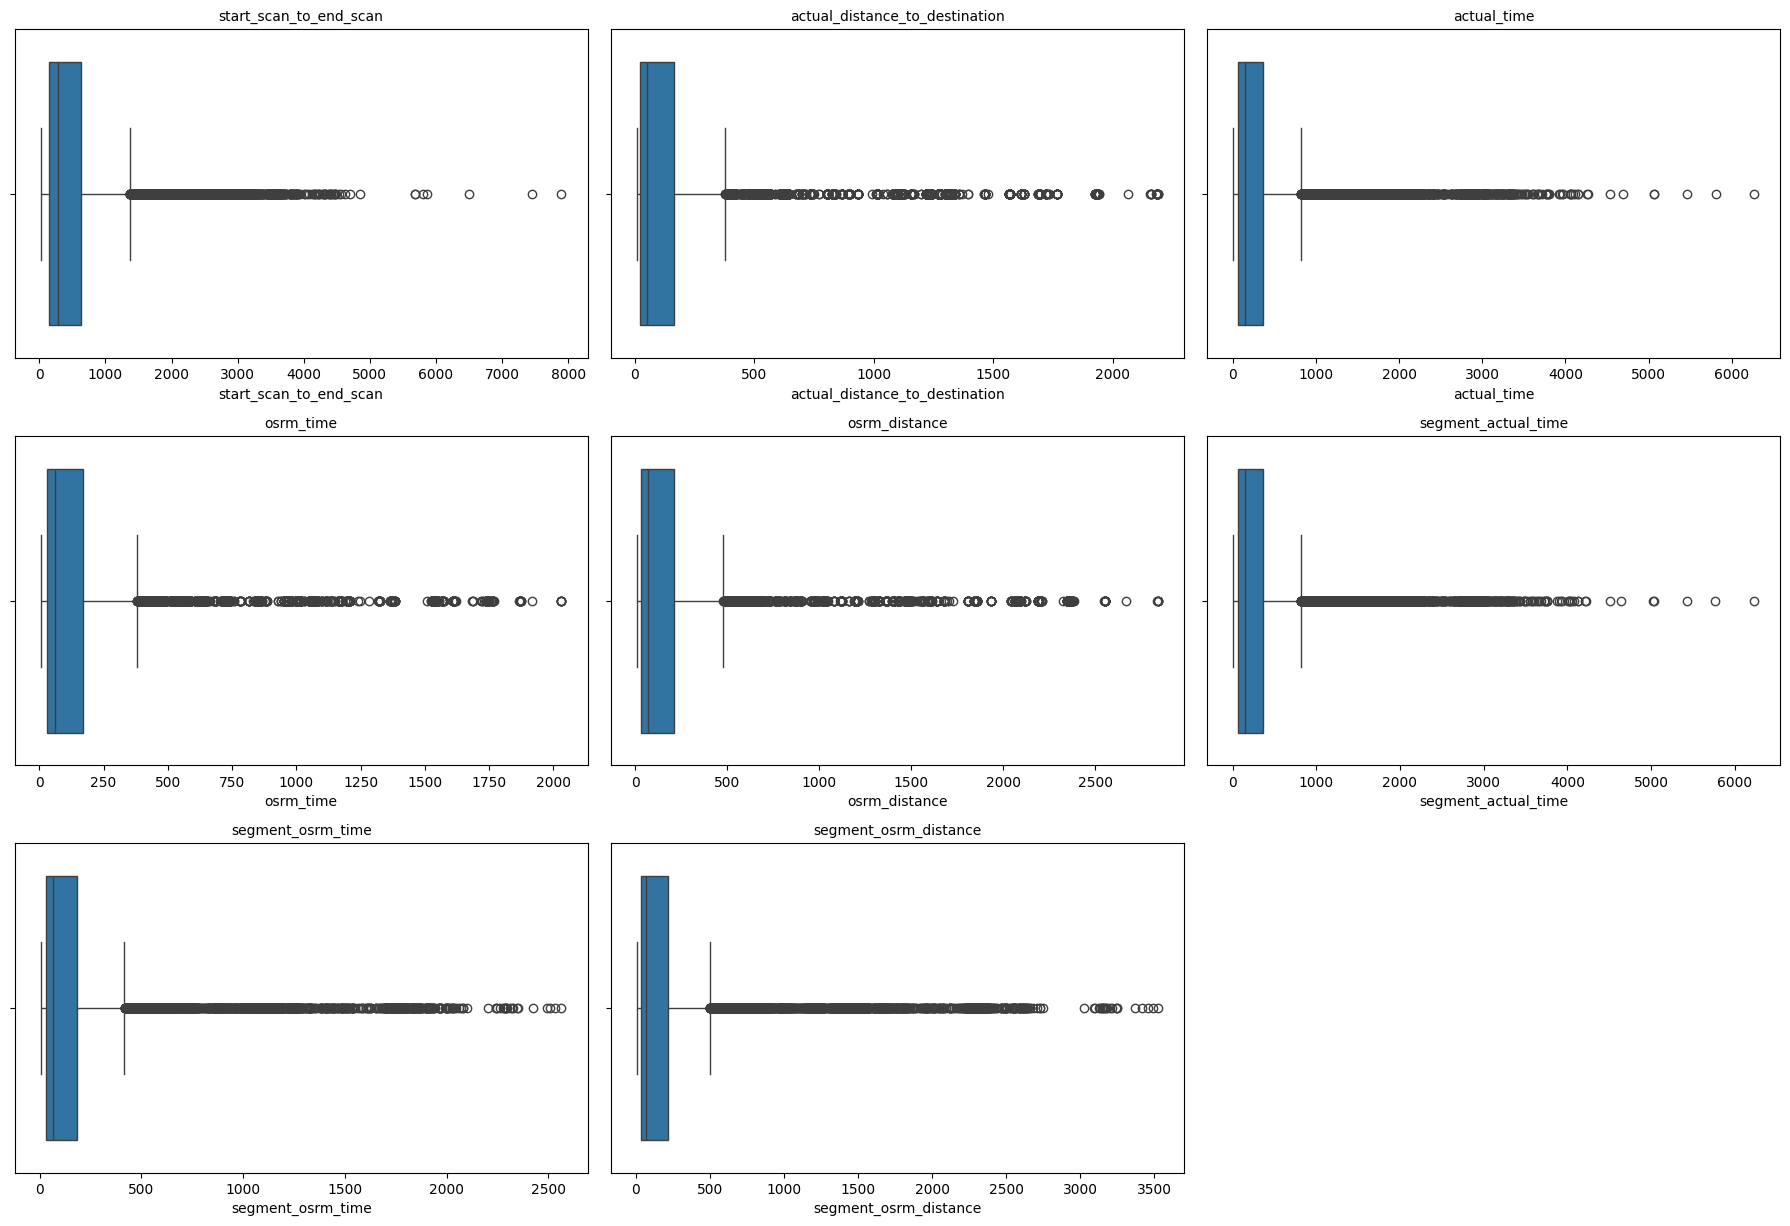

In [ ]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18,16))

axes = axes.flatten()

for i, col in enumerate(num_cols_trip):
    sns.boxplot(x=trip_df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=10)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
for col in num_cols_trip:
    Q1 = trip_df[col].quantile(0.25)
    Q3 = trip_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    trip_df[col] = np.where(trip_df[col] < lower, lower, trip_df[col])
    trip_df[col] = np.where(trip_df[col] > upper, upper, trip_df[col])

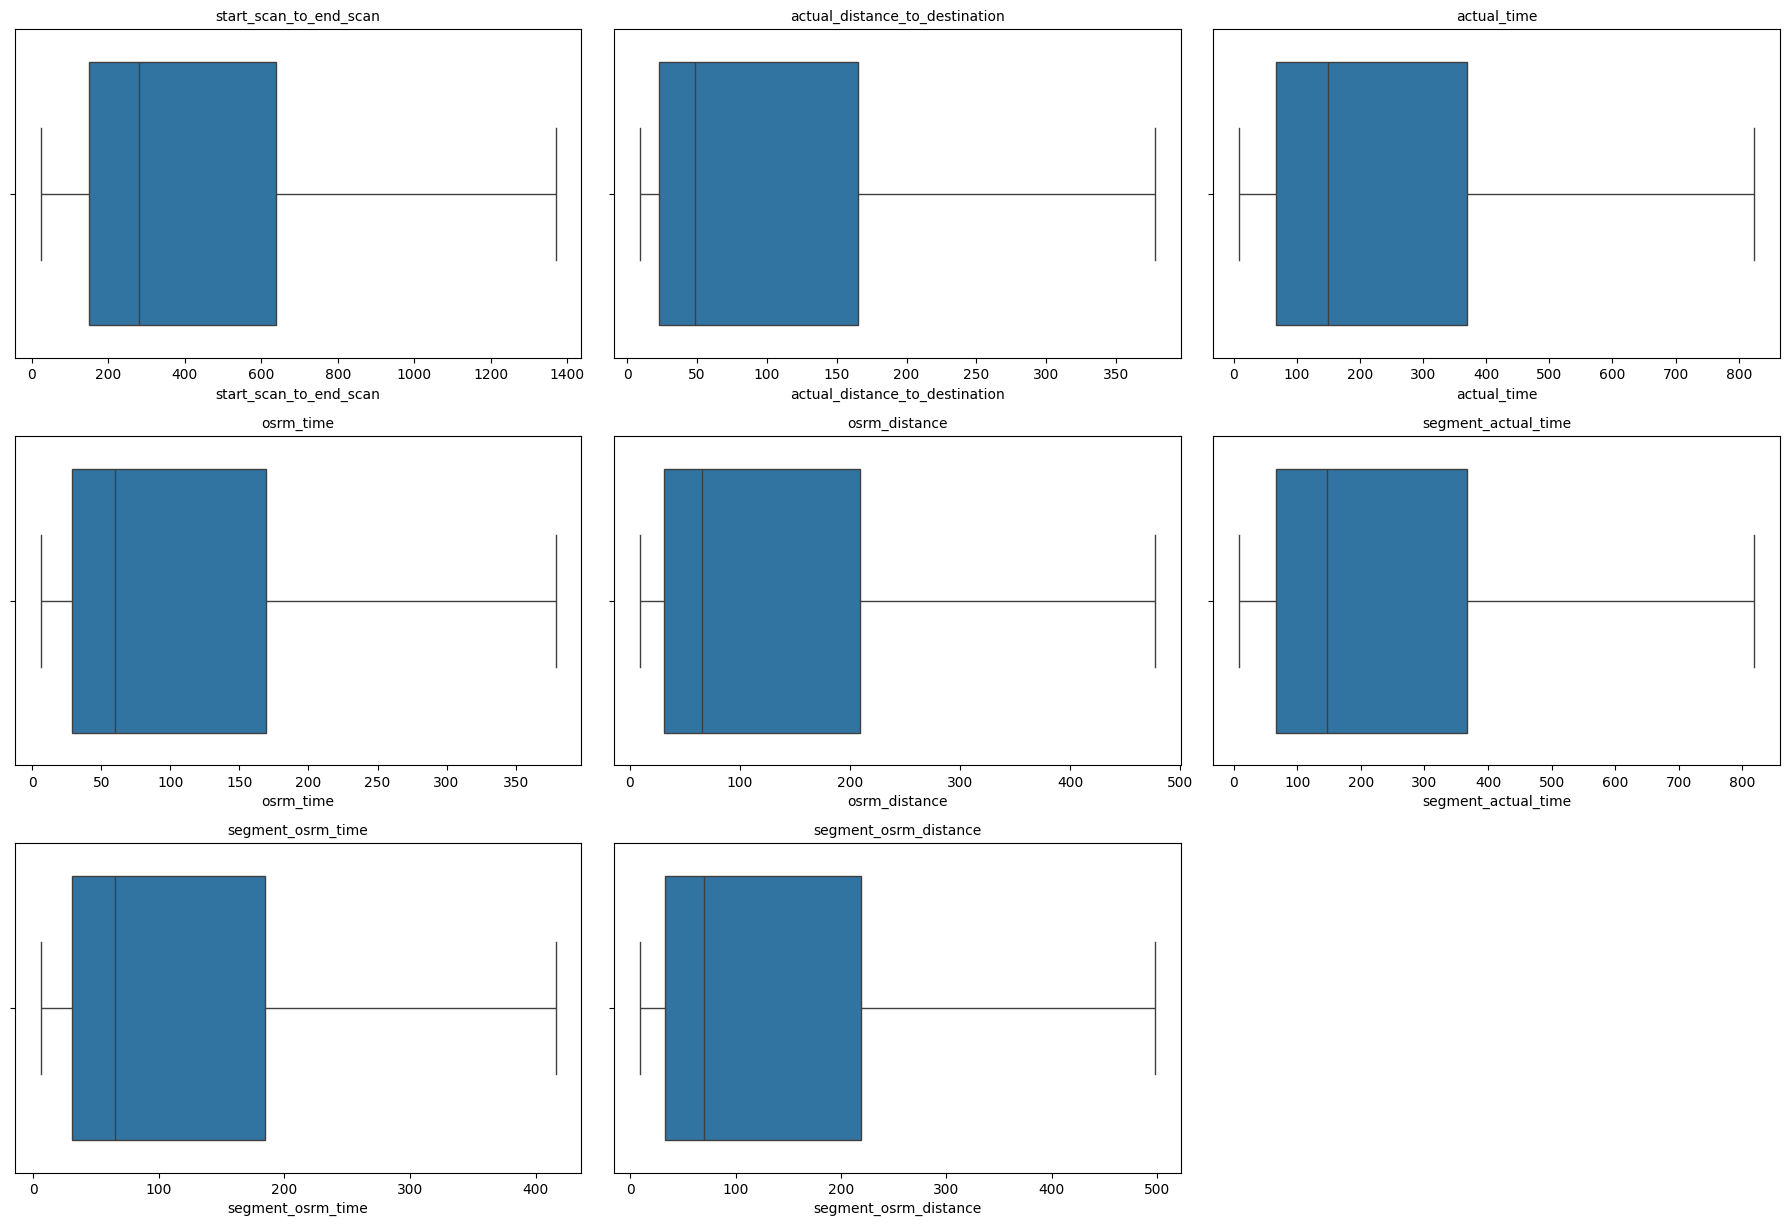

In [ ]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18,16))

axes = axes.flatten()

for i, col in enumerate(num_cols_trip):
    sns.boxplot(x=trip_df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=10)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Missing Value & Outlier Analysis

- Missing values were very minimal and limited to location-related fields such as source_name, destination_name, and source_state.
- Missing location values were treated using corresponding center/location information to preserve operational records and avoid unnecessary data loss.
- After treatment, the dataset contained no missing values.

- Outlier analysis revealed that most numerical variables are heavily right-skewed with several extreme observations.
- Significant outliers were observed mainly in:
  - actual_time
  - osrm_time
  - osrm_distance
  - segment_actual_time
  - segment_osrm_distance
  - start_scan_to_end_scan

- These extreme values are operationally possible in logistics datasets due to:
  - long-distance deliveries,
  - traffic conditions,
  - shipment delays,
  - and exceptional routing scenarios.

- Since outliers can heavily influence statistical analysis and machine learning models, IQR-based outlier treatment will be applied in the next step to improve data consistency and model performance.

**Observations after Outlier Treatment**

- Outliers were treated using the IQR (Interquartile Range) method to reduce the impact of extreme values.
- After treatment, numerical variables show more controlled distributions with reduced spread and fewer extreme observations.
- Time and distance-related features still preserve their overall trends while becoming more suitable for statistical analysis and machine learning models.
- Outlier handling improved data consistency and reduced the influence of abnormal operational records.

# Checking relationship between aggregated fields

In [ ]:
agg_cols = ['actual_time','osrm_time','osrm_distance','segment_actual_time','segment_osrm_time','segment_osrm_distance','actual_distance_to_destination']

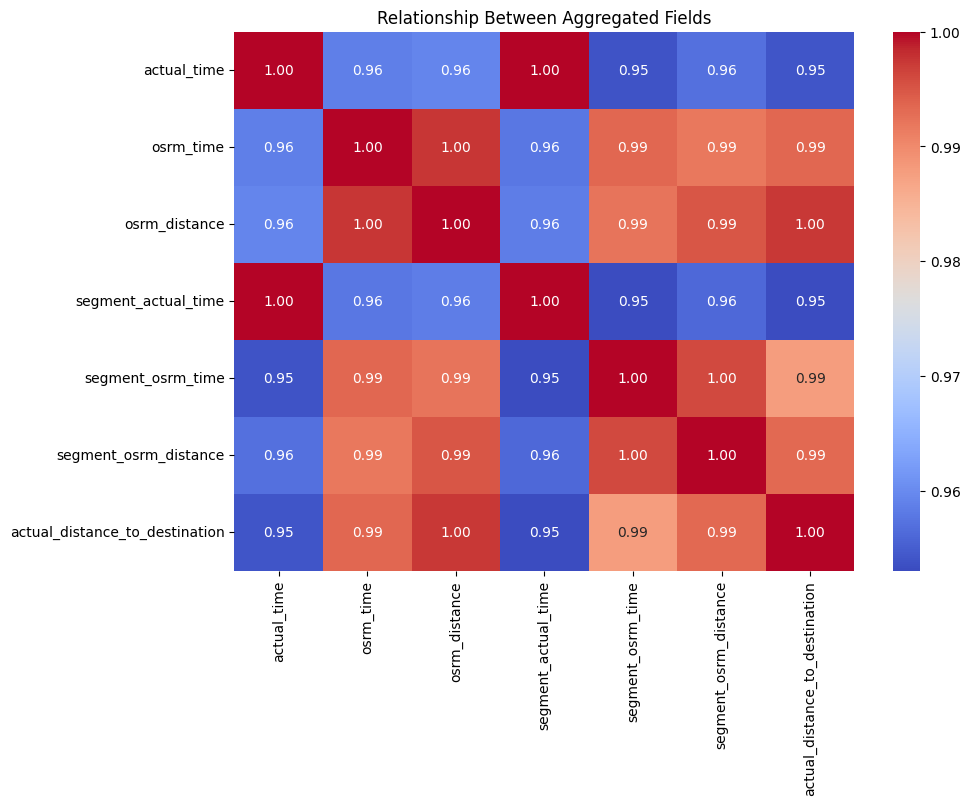

In [ ]:
plt.figure(figsize=(10,7))
sns.heatmap(trip_df[agg_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Relationship Between Aggregated Fields')
plt.show()

In [ ]:
trip_df[agg_cols].corr()

,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,actual_distance_to_destination
actual_time,1.000000,0.958590,0.959289,0.999989,0.953872,0.956967,0.954076
osrm_time,0.958590,1.000000,0.997587,0.957761,0.993551,0.991812,0.993527
osrm_distance,0.959289,0.997587,1.000000,0.958427,0.992145,0.994963,0.997272
segment_actual_time,0.999989,0.957761,0.958427,1.000000,0.953039,0.956106,0.953142
segment_osrm_time,0.953872,0.993551,0.992145,0.953039,1.000000,0.996092,0.987727
segment_osrm_distance,0.956967,0.991812,0.994963,0.956106,0.996092,1.000000,0.993257
actual_distance_to_destination,0.954076,0.993527,0.997272,0.953142,0.987727,0.993257,1.000000


# Relationship Between Aggregated Fields

- Strong positive correlations are observed among actual_time, osrm_time, osrm_distance, and actual_distance_to_destination.
- actual_time and segment_actual_time show an almost perfect correlation (~1.00), confirming consistency in segment-level aggregation.
- osrm_time and osrm_distance are highly correlated, indicating that route distance strongly influences estimated travel time.
- segment_osrm_time and segment_osrm_distance also show very strong relationships, validating the reliability of segment-based route estimation.
- High correlations among aggregated variables indicate that the merging and aggregation process preserved operational consistency across trips.

# Handling categorical values



In [ ]:
trip_df = pd.get_dummies(trip_df, columns=['route_type','data'], drop_first=True)

# Handling Categorical Variables

- One-Hot Encoding was applied only to relevant low-cardinality categorical variables.
- High-cardinality identifiers such as trip_uuid, route_schedule_uuid, source_center, and destination_center were not encoded because they do not provide meaningful predictive value and would unnecessarily increase dimensionality.
- Location and timestamp fields were retained for feature engineering and analytical purposes.

# Column Normalization /Column Standardization

In [ ]:
scale_cols = trip_df.select_dtypes(include=['int64','float64']).columns

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
trip_df[scale_cols] = scaler.fit_transform(trip_df[scale_cols])
trip_df[scale_cols].head()

,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance
0,2.233897,2.284448,2.148616,2.250990,2.277214,2.149256,2.256743,2.262408
1,-0.667044,-0.306912,-0.463140,-0.406587,-0.365915,-0.465311,-0.475861,-0.404369
2,2.233897,2.284448,2.148616,2.250990,2.277214,2.149256,2.256743,2.262408
3,-0.862229,-0.783339,-0.785059,-0.859486,-0.807401,-0.781760,-0.857336,-0.818804
4,0.643137,0.154629,0.295668,0.012131,0.050268,0.302658,-0.086601,-0.000954


# Observations after Standardization

- Numerical features were standardized using StandardScaler to bring all variables onto a common scale.
- After scaling, features are centered around mean ≈ 0 with standardized variance.
- Standardization helps prevent large-scale variables from dominating machine learning models.
- Scaling improves model stability, convergence speed, and overall analytical consistency.
- Time and distance-related variables are now suitable for further predictive modeling and statistical analysis.

In [ ]:
top_states = trip_df['source_state'].value_counts().head(10)
top_destination_states = trip_df['destination_state'].value_counts().head(10)
top_source_states = trip_df['source_state'].value_counts().head(10)
trip_df['state_corridor'] = trip_df['source_state'] + ' → ' + trip_df['destination_state']
trip_df['city_corridor'] = trip_df['source_city'] + ' → ' + trip_df['destination_city']
top_state_corridors = trip_df['state_corridor'].value_counts().head(10)
top_city_corridors = trip_df['city_corridor'].value_counts().head(10)
corridor_performance = trip_df.groupby('city_corridor')[['actual_distance_to_destination','actual_time','osrm_time','segment_actual_time']].mean().sort_values(by='actual_time', ascending=False).head(10)
state_performance = trip_df.groupby('source_state')[['actual_distance_to_destination','actual_time','osrm_time']].mean().sort_values(by='actual_time', ascending=False).head(10)
trip_df['delay_gap'] = trip_df['actual_time'] - trip_df['osrm_time']
delay_corridors = trip_df.groupby('city_corridor')[['delay_gap','actual_time','osrm_time']].mean().sort_values(by='delay_gap', ascending=False).head(10)
trip_df.groupby('source_state')['delay_gap'].mean().sort_values(ascending=False).head(10)
trip_df['distance_bucket'] = pd.cut(trip_df['actual_distance_to_destination'], bins=5)



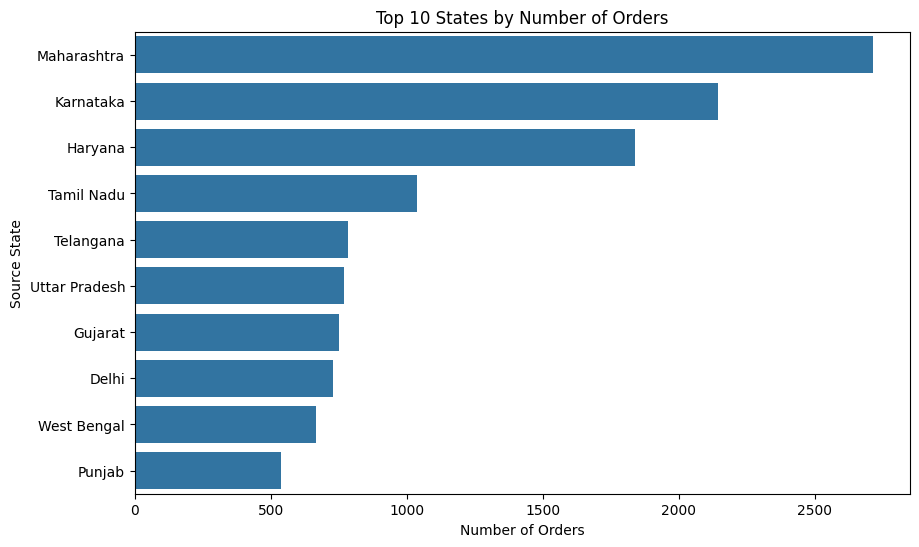

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_states.values, y=top_states.index)
plt.xlabel('Number of Orders')
plt.ylabel('Source State')
plt.title('Top 10 States by Number of Orders')
plt.show()

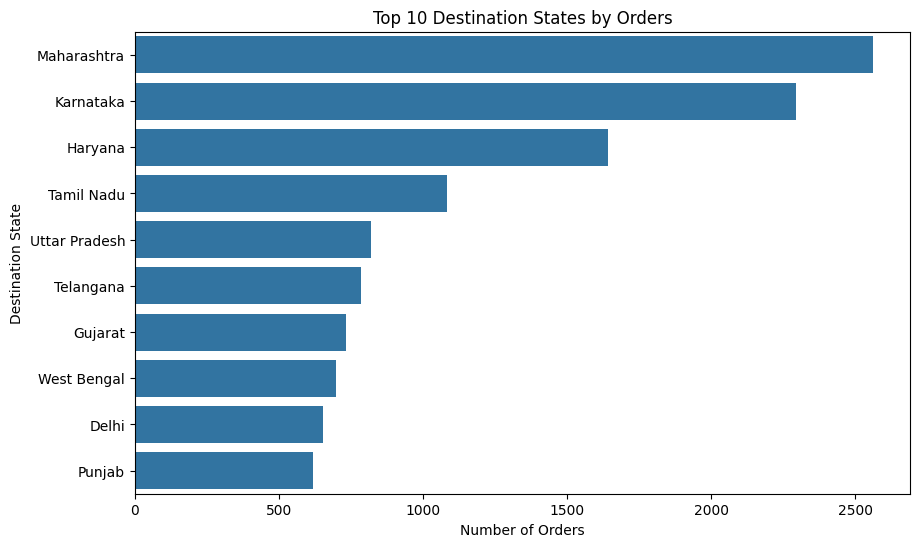

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_destination_states.values, y=top_destination_states.index)
plt.title('Top 10 Destination States by Orders')
plt.xlabel('Number of Orders')
plt.ylabel('Destination State')
plt.show()

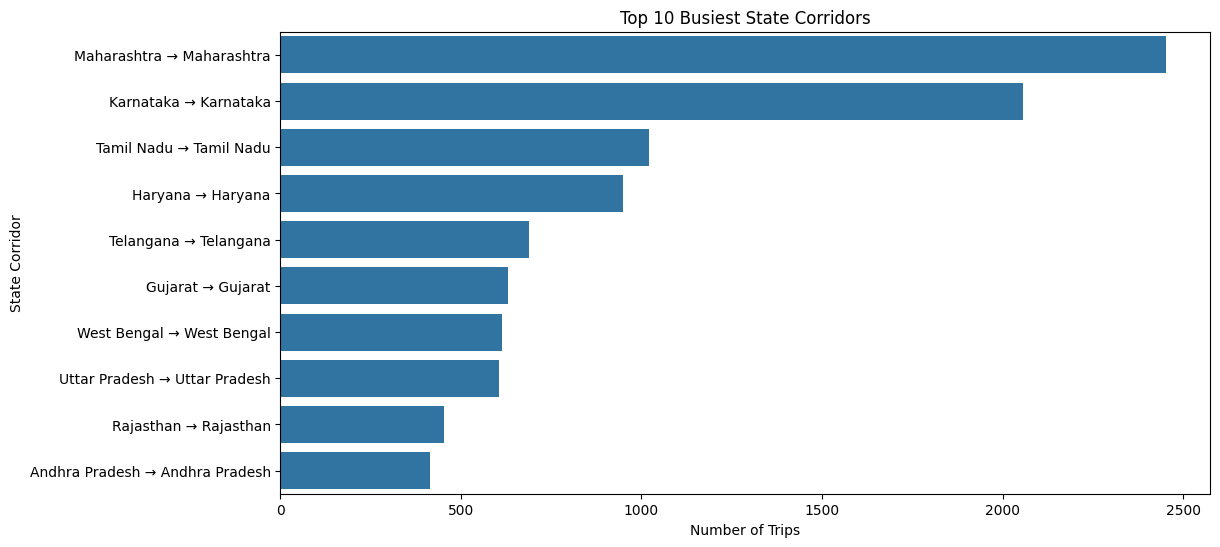

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x=top_state_corridors.values, y=top_state_corridors.index)
plt.title('Top 10 Busiest State Corridors')
plt.xlabel('Number of Trips')
plt.ylabel('State Corridor')
plt.show()

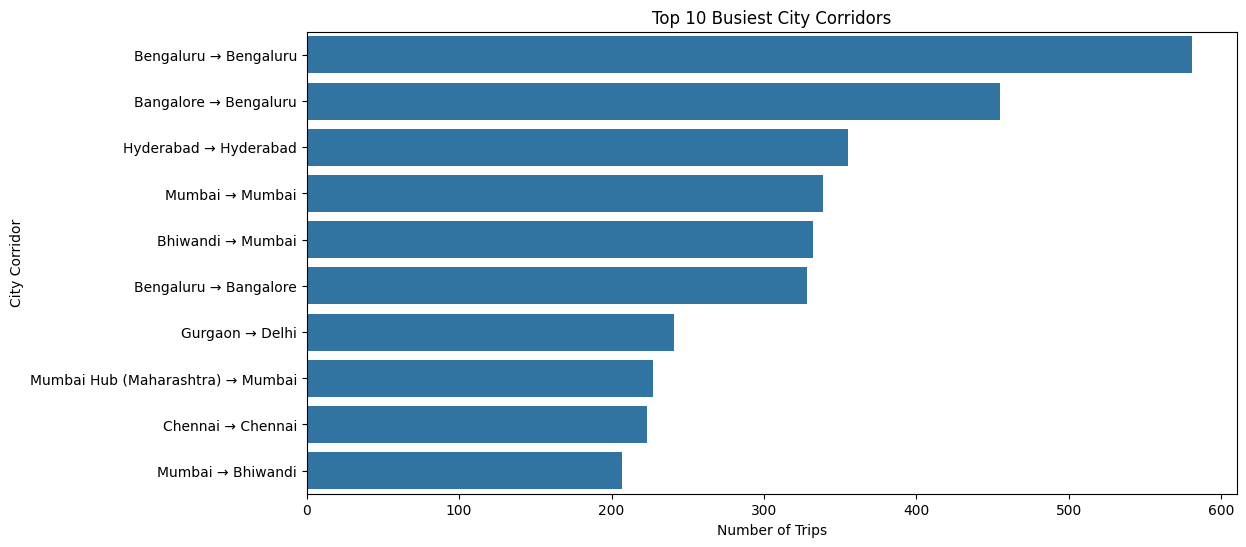

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x=top_city_corridors.values, y=top_city_corridors.index)
plt.title('Top 10 Busiest City Corridors')
plt.xlabel('Number of Trips')
plt.ylabel('City Corridor')
plt.show()

In [ ]:
trip_df.groupby('distance_bucket')[['actual_time','osrm_time','delay_gap']].mean()

,actual_time,osrm_time,delay_gap
distance_bucket,,,
"(-0.856, -0.225]",-0.609644,-0.654171,0.044526
"(-0.225, 0.402]",0.110484,0.095966,0.014518
"(0.402, 1.03]",0.636132,0.654778,-0.018647
"(1.03, 1.657]",1.066228,1.272458,-0.206230
"(1.657, 2.284]",2.031628,2.178774,-0.147146


In [ ]:
trip_df.groupby('distance_bucket')[['actual_time','osrm_time','delay_gap']].mean()

,actual_time,osrm_time,delay_gap
distance_bucket,,,
"(-0.856, -0.225]",-0.609644,-0.654171,0.044526
"(-0.225, 0.402]",0.110484,0.095966,0.014518
"(0.402, 1.03]",0.636132,0.654778,-0.018647
"(1.03, 1.657]",1.066228,1.272458,-0.206230
"(1.657, 2.284]",2.031628,2.178774,-0.147146


# Business Insights & Observations

## 1. High Logistics Concentration in Few States

- Maharashtra emerged as the highest shipment-generating state, followed by Karnataka and Haryana.
- Southern and western states collectively dominate logistics activity, indicating:
  - stronger industrial ecosystems,
  - higher customer density,
  - and better warehousing infrastructure.

### Business Impact
- These regions likely contribute a major share of revenue and operational workload.
- Higher fleet allocation and hub optimization should be prioritized in these states.

---

## 2. Corridor-Based Traffic Concentration

- A small number of state and city corridors contribute disproportionately high trip volumes.
- Certain intra-state and metro-connected corridors appear repeatedly as the busiest routes.

### Business Impact
- These corridors represent critical logistics arteries for the company.
- Congestion, delays, or operational failures in these routes can significantly affect overall delivery performance.

---

## 3. Strong Relationship Between Distance and Delivery Time

- actual_time, osrm_time, osrm_distance, and actual_distance_to_destination showed very high positive correlations.
- As trip distance increases, delivery time increases almost proportionally.

### Business Impact
- Route distance is one of the strongest drivers of delivery performance.
- Distance-based forecasting models are likely to perform effectively.

---

## 4. OSRM Estimates Closely Match Actual Operations

- actual_time and osrm_time showed extremely high correlation (~0.96).
- segment_actual_time and aggregated actual_time showed near-perfect alignment (~1.00).

### Business Impact
- OSRM-generated route estimates are operationally reliable.
- The company can confidently use OSRM features for:
  - ETA prediction,
  - route optimization,
  - and delivery planning.

---

## 5. Segment-Level Aggregation is Highly Consistent

- Aggregated segment metrics closely reconstructed trip-level metrics.
- segment_osrm_distance and osrm_distance also showed near-perfect consistency.

### Business Impact
- The data engineering pipeline is structurally reliable.
- Segment-level operational monitoring can effectively support trip-level forecasting.

---

## 6. Presence of Heavy Operational Variability

- Most time and distance variables were heavily right-skewed with large outliers.
- A few trips showed exceptionally high travel times and distances.

### Business Interpretation
These may represent:
- long-haul routes,
- traffic congestion,
- shipment delays,
- failed delivery attempts,
- or operational bottlenecks.

---

## 7. Longer Routes Show Increasing Delay Variability

- Distance bucket analysis showed that delivery behavior becomes more variable as route length increases.
- Higher-distance routes showed larger differences between actual_time and osrm_time.

### Business Impact
- Long-distance corridors are operationally more unpredictable.
- These routes may require:
  - better scheduling buffers,
  - dynamic routing,
  - and real-time traffic adjustments.

---

## 8. Data Quality and Model Readiness

- Missing values were minimal and handled successfully.
- Outliers were treated using the IQR method.
- Numerical variables were standardized for machine learning readiness.

### Business Impact
- The final processed dataset is suitable for:
  - forecasting,
  - ETA prediction,
  - operational analytics,
  - and delivery performance modeling.

# Recommendations

## Operational Recommendations

- Prioritize optimization of high-volume corridors through:
  - dedicated fleet planning,
  - faster loading/unloading operations,
  - and hub-level process improvements.

- Introduce dynamic monitoring for long-distance routes where delivery variability is highest.

- Use segment-level tracking more aggressively for early delay detection and operational alerts.

---

## Forecasting & Analytics Recommendations

- Use OSRM-based variables as primary features for predictive modeling since they strongly align with actual delivery behavior.

- Develop route-level delay prediction models using:
  - distance,
  - corridor,
  - route type,
  - and time-based features.

- Build state-wise operational dashboards for tracking:
  - delivery performance,
  - average delays,
  - and corridor efficiency.

---

## Data Engineering Recommendations

- Maintain segment-level granularity in pipelines since it provides strong reconstruction capability for trip-level analysis.

- Introduce automated anomaly monitoring for:
  - negative segment times,
  - extreme delays,
  - and abnormal route deviations.

- Periodically retrain forecasting models using updated traffic and route behavior patterns.